# Experimental comparisons and ablations

This notebook compares baseline training against annulus balancing and annulus boundary weighting at every training-noise level. Outputs use `output/experiments/train_sigma.../<condition>/test_sigma...`. It preserves clean validation/test data for the official metric. Soft-IoU support is opt-in and is not silently promoted into the baseline.

A condition is promoted only if annulus IoU improves without materially reducing overall random-test IoU. The quick screen uses 5,000 training samples and 80 epochs; repeat the winner with full settings before changing notebook `01`.


=== training sigma=0, condition=baseline ===


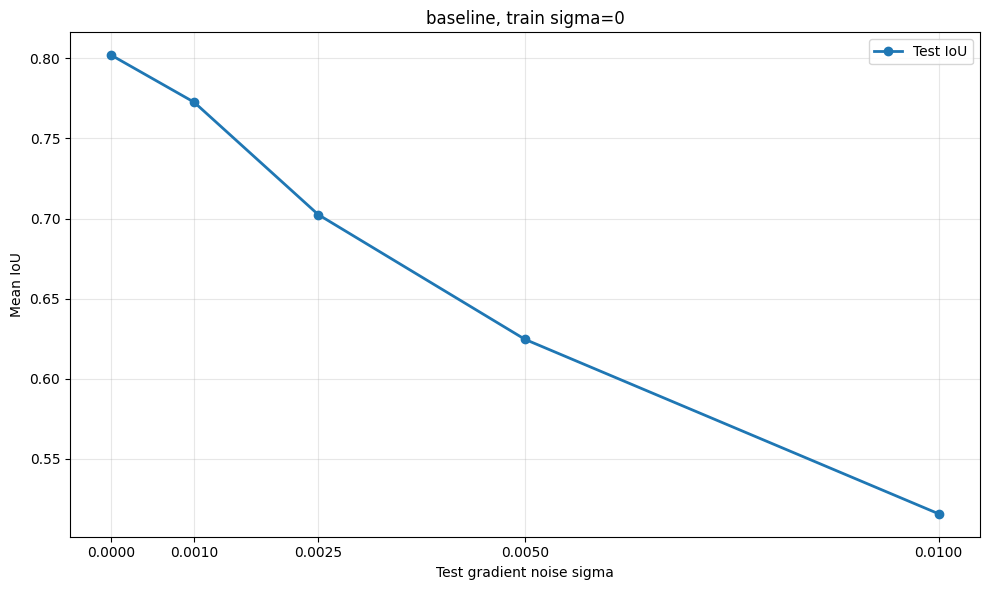

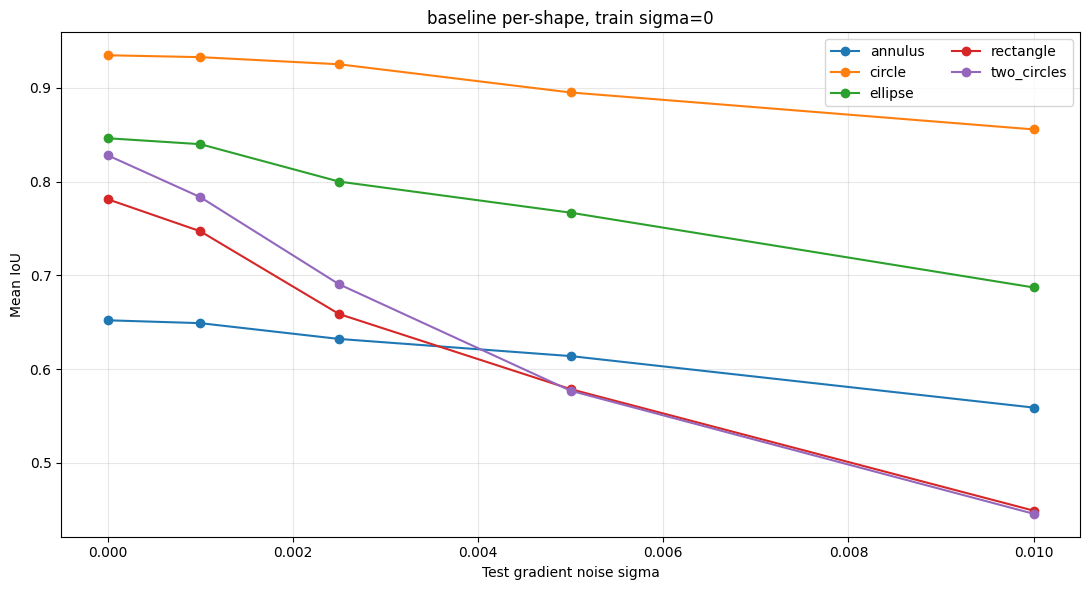


=== training sigma=0, condition=annulus_balanced ===


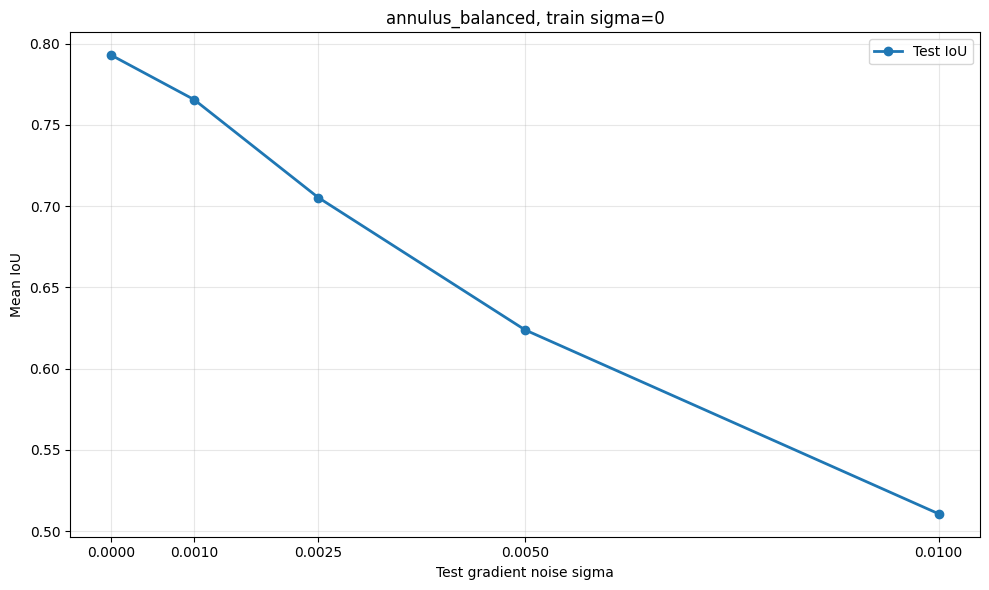

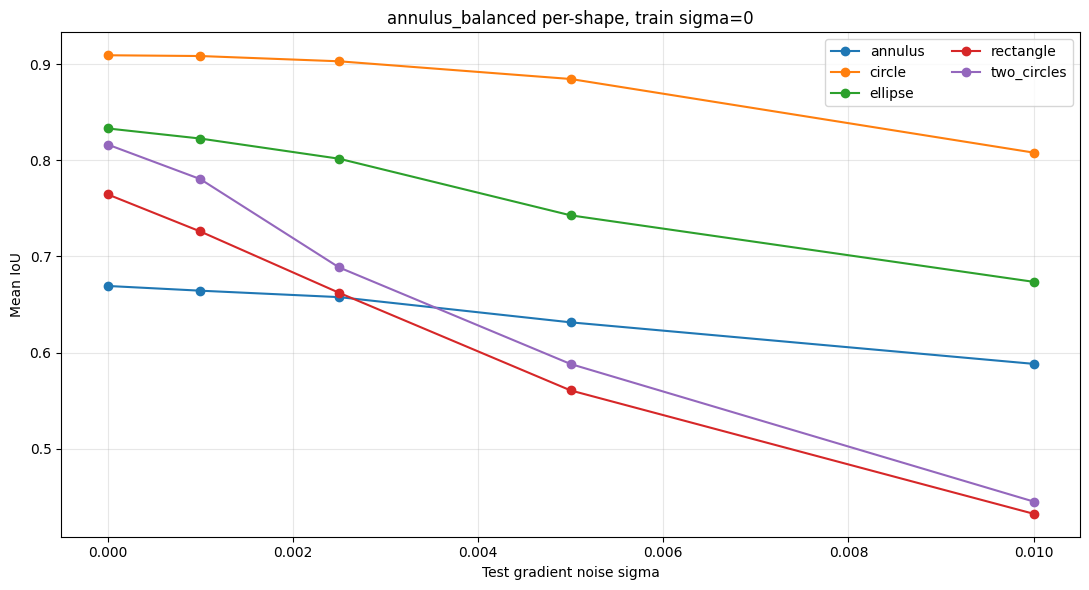


=== training sigma=0, condition=annulus_balanced_weighted ===


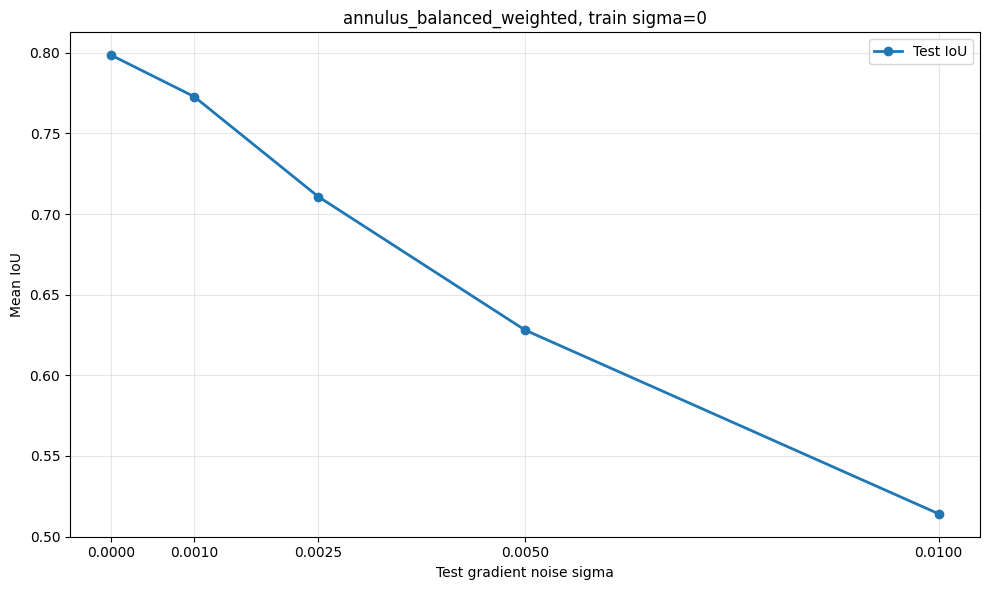

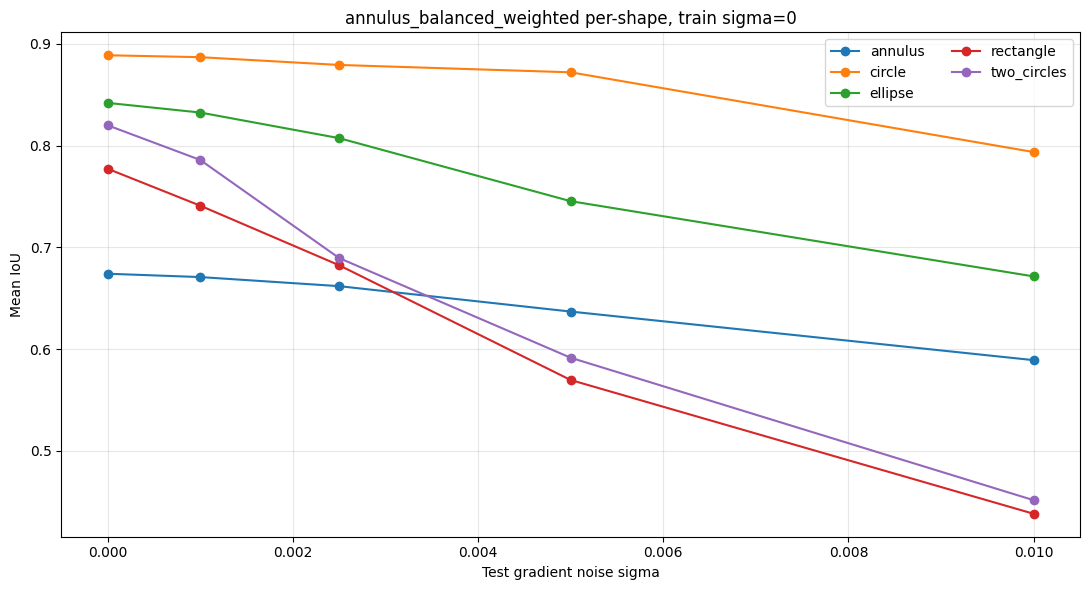


=== training sigma=0.001, condition=baseline ===


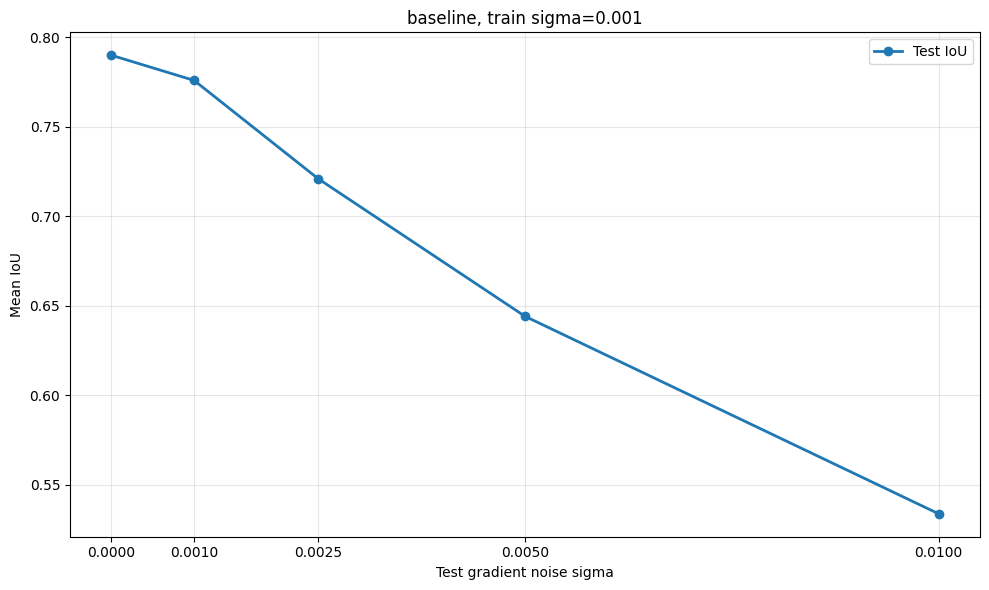

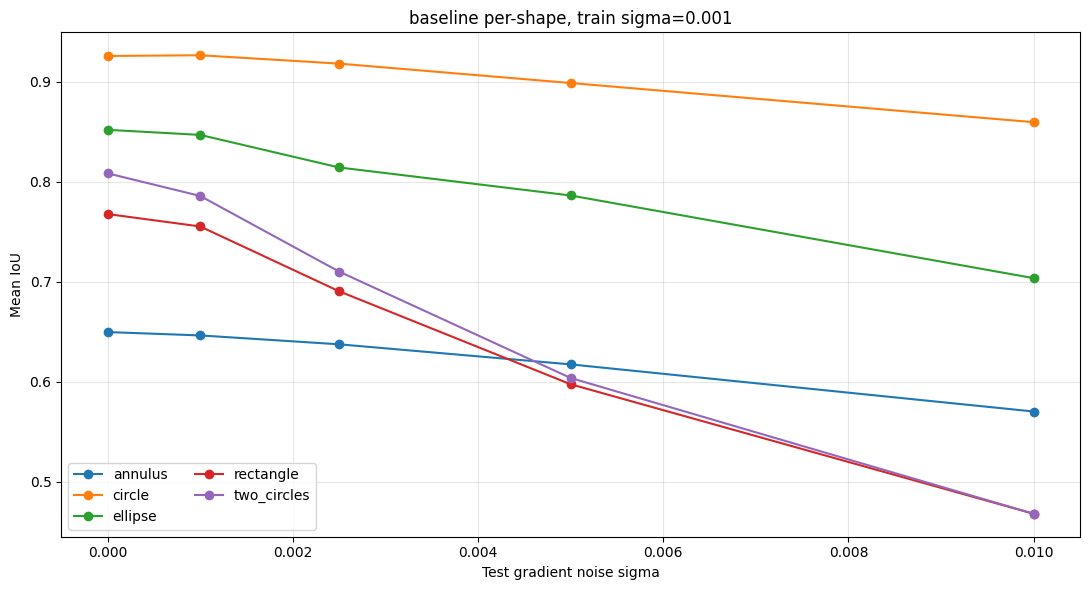


=== training sigma=0.001, condition=annulus_balanced ===


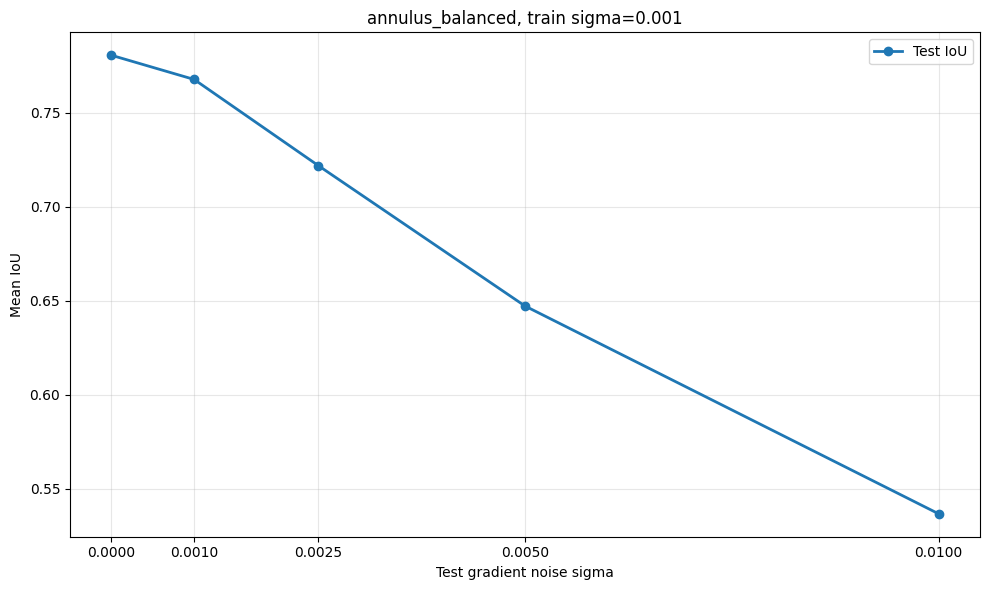

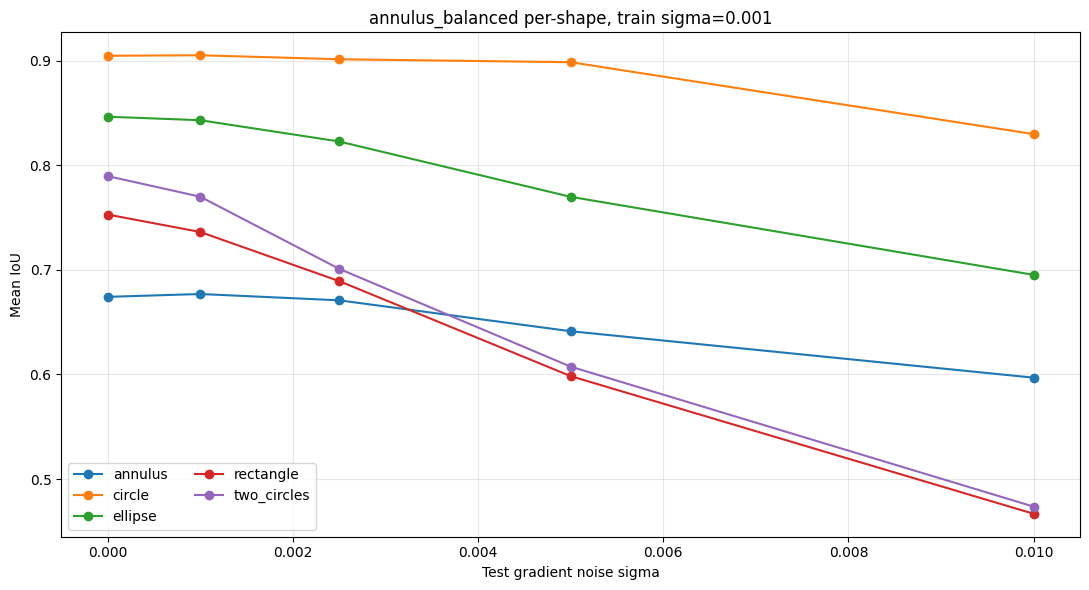


=== training sigma=0.001, condition=annulus_balanced_weighted ===


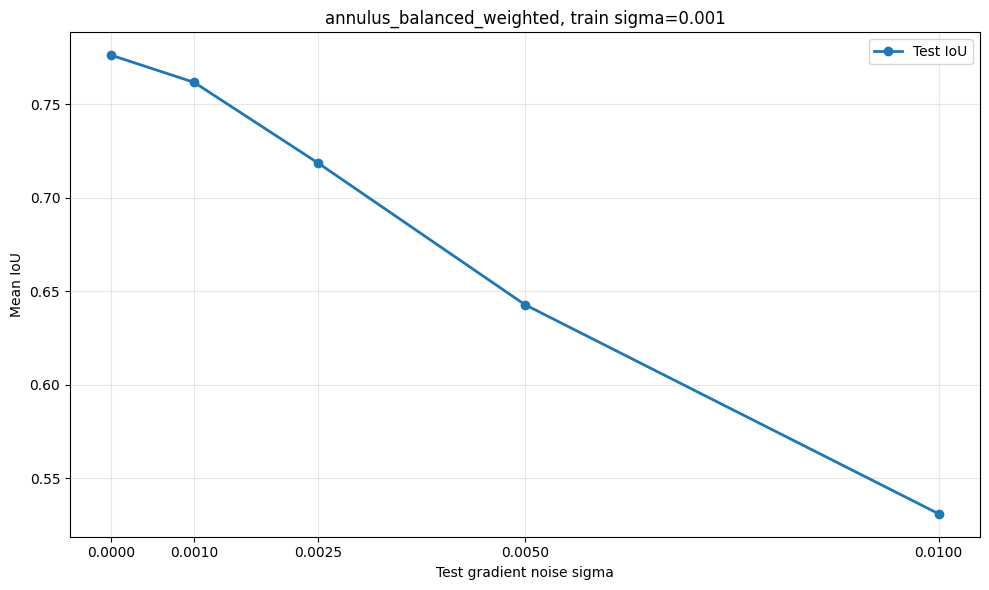

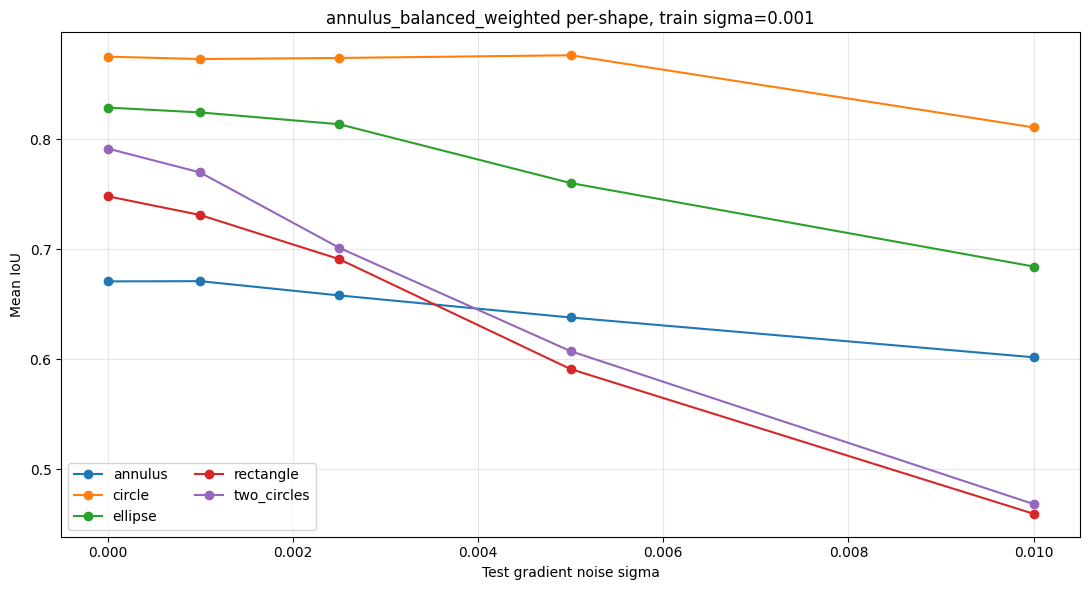


=== training sigma=0.0025, condition=baseline ===


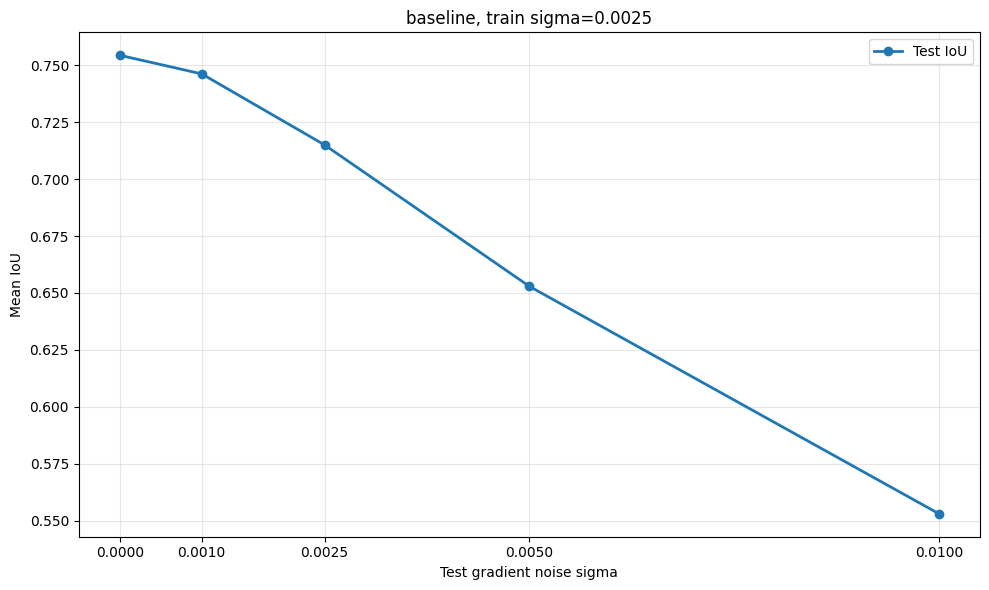

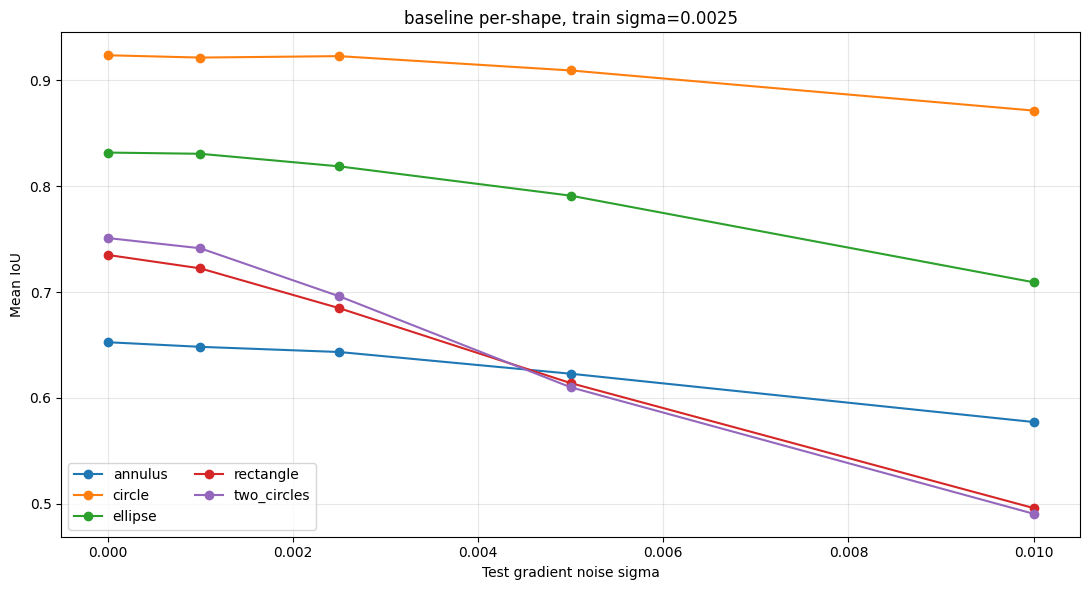


=== training sigma=0.0025, condition=annulus_balanced ===


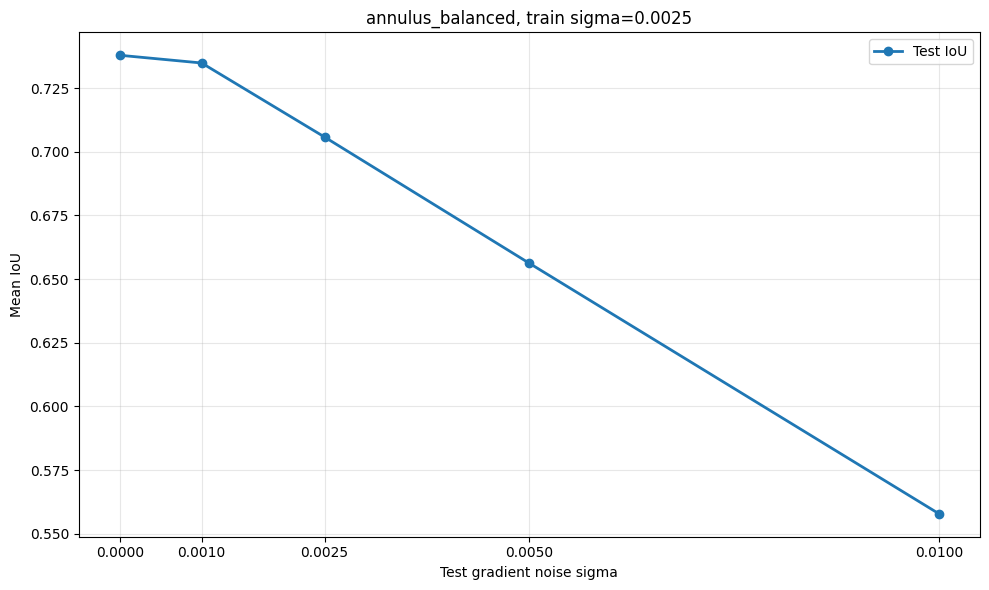

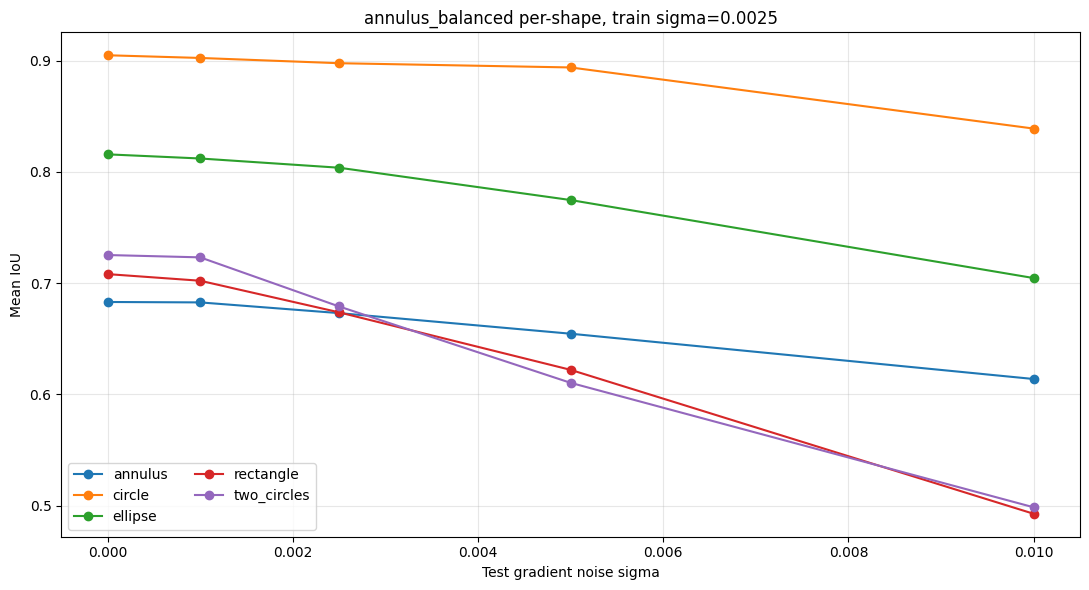


=== training sigma=0.0025, condition=annulus_balanced_weighted ===


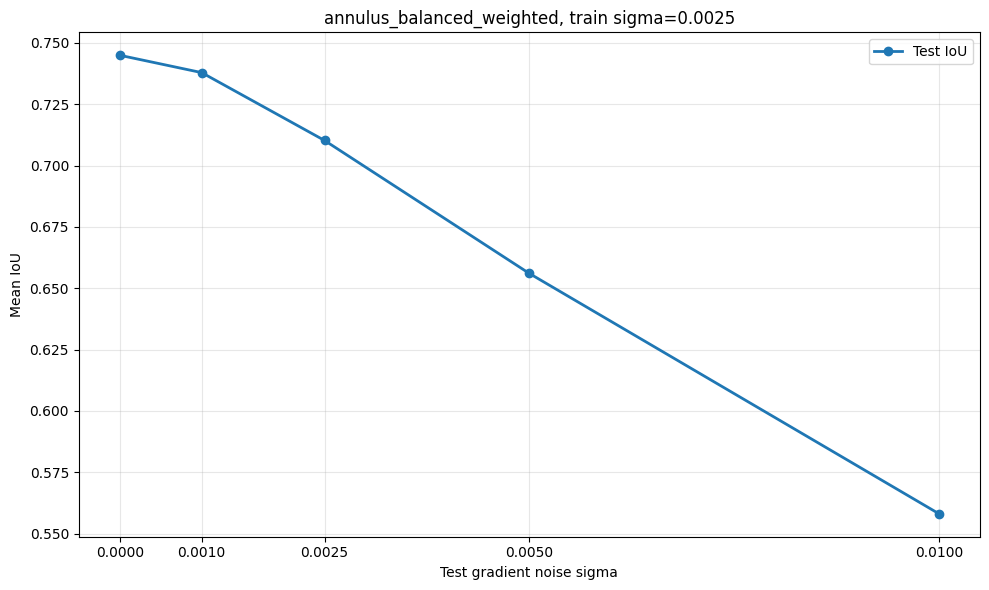

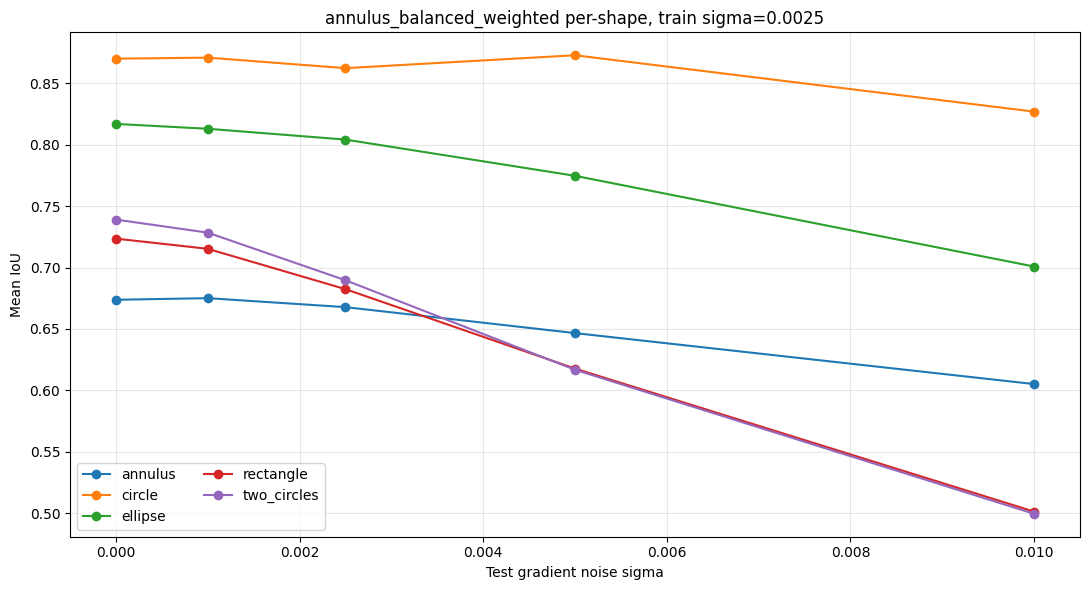


=== training sigma=0.005, condition=baseline ===


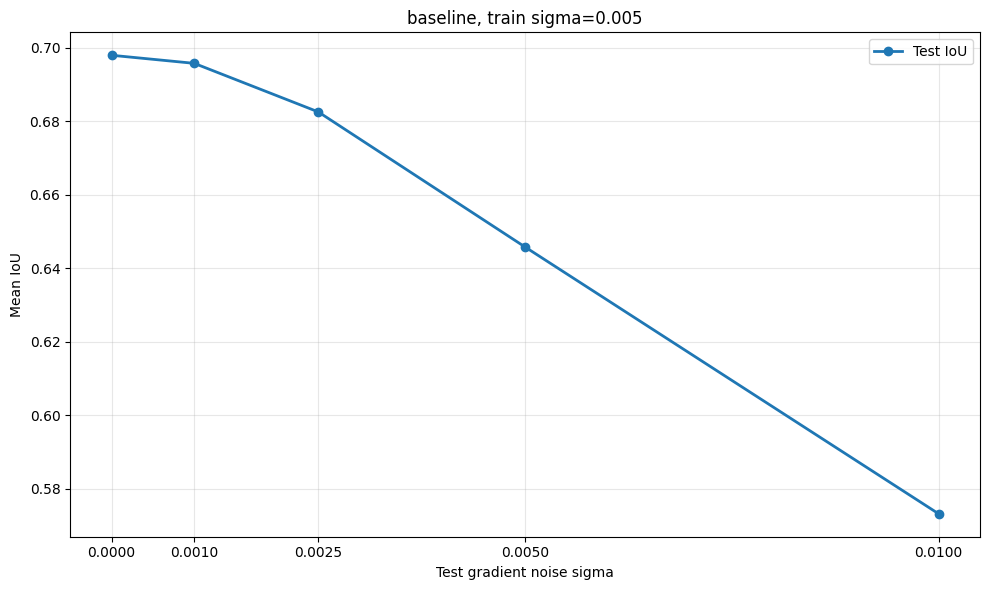

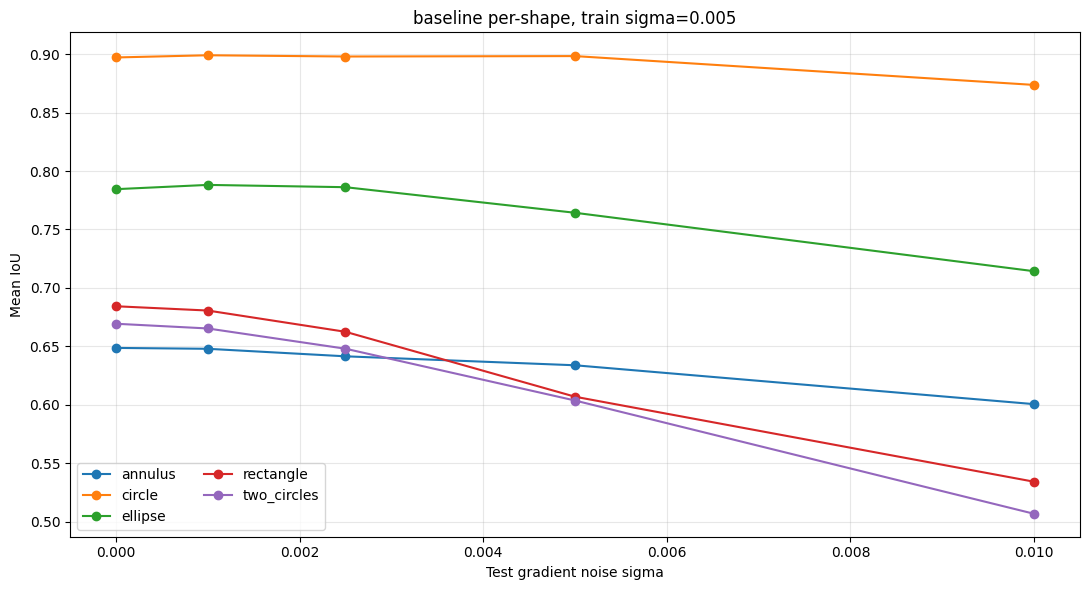


=== training sigma=0.005, condition=annulus_balanced ===


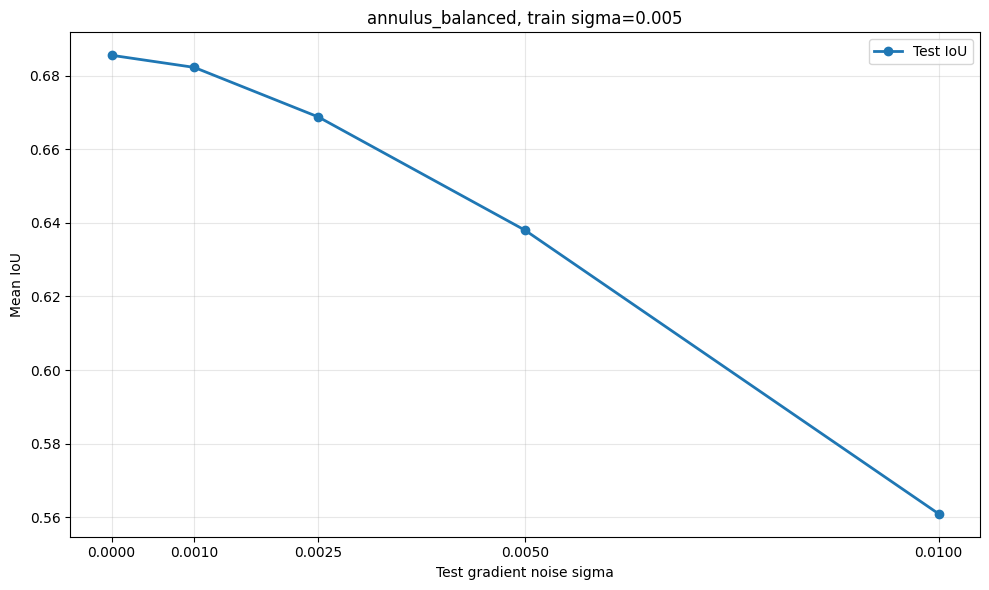

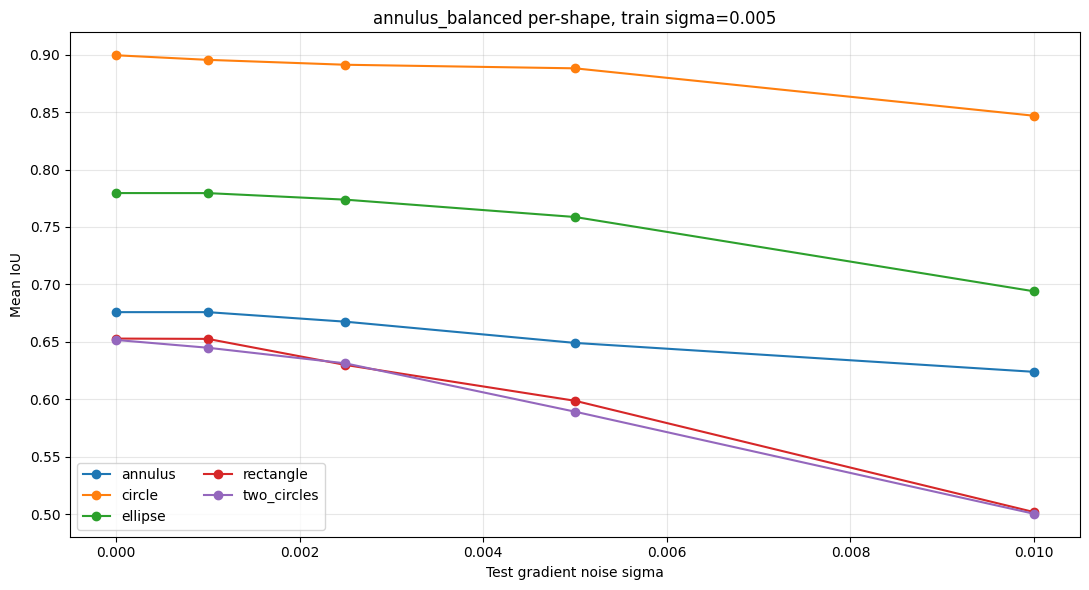


=== training sigma=0.005, condition=annulus_balanced_weighted ===


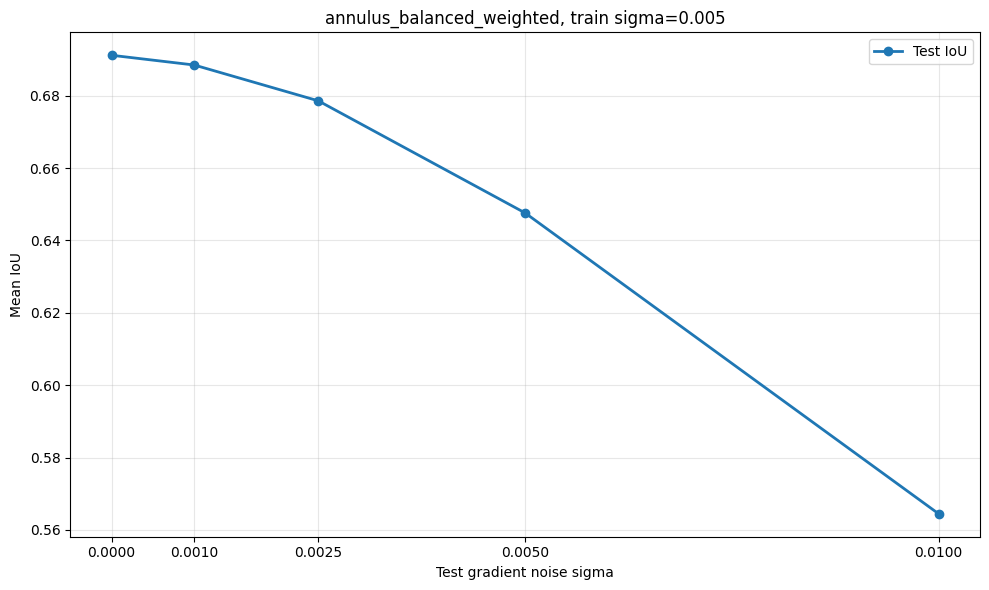

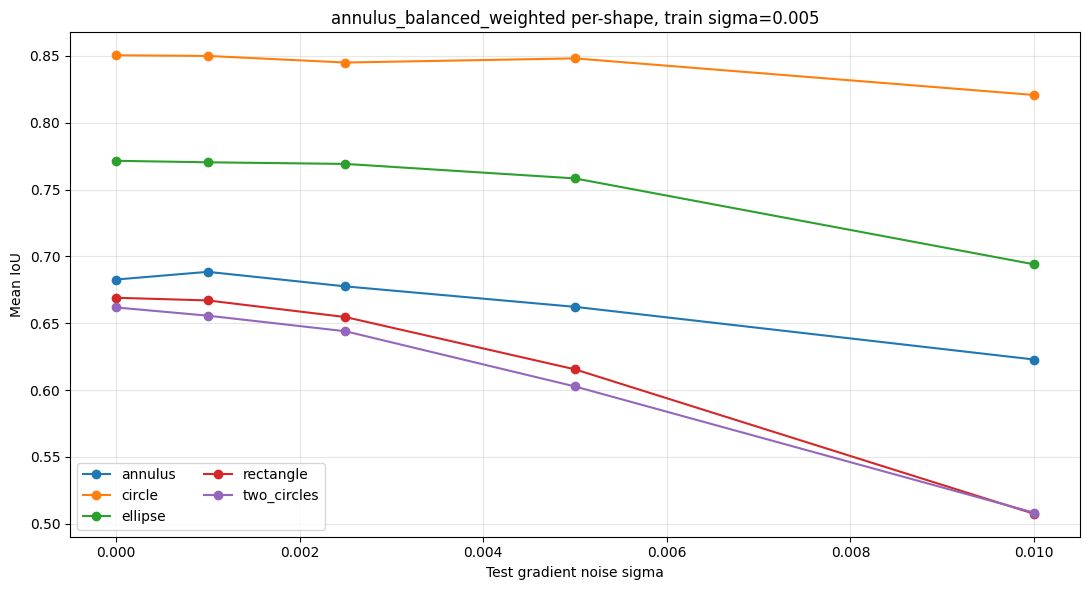


=== training sigma=0.01, condition=baseline ===


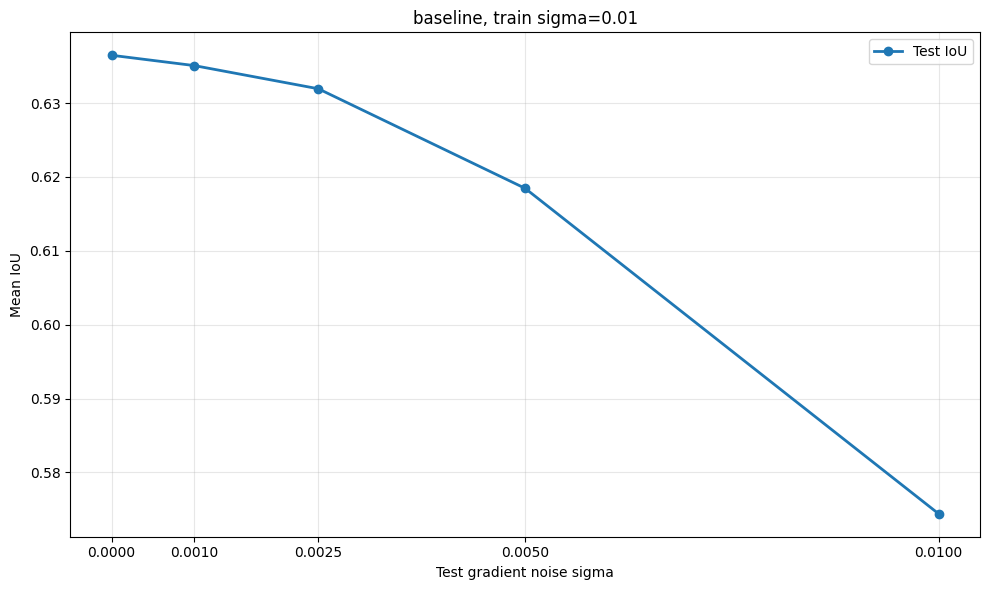

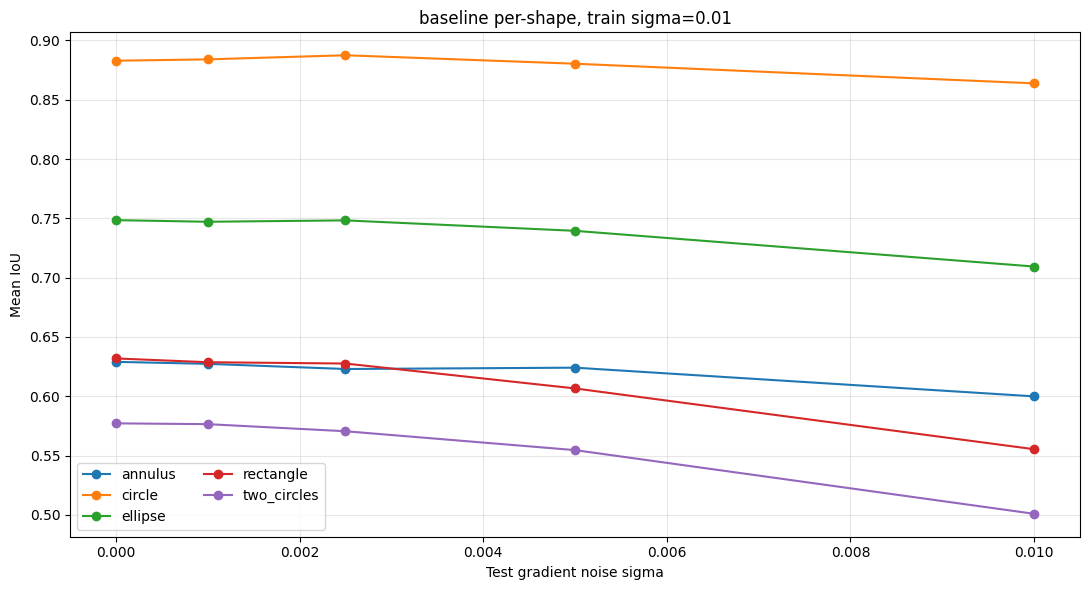


=== training sigma=0.01, condition=annulus_balanced ===


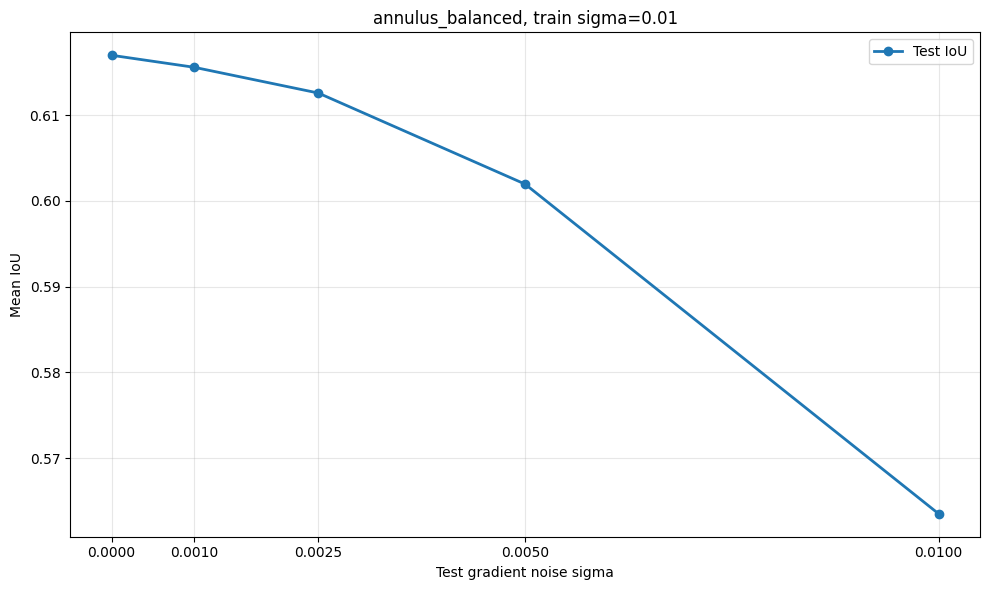

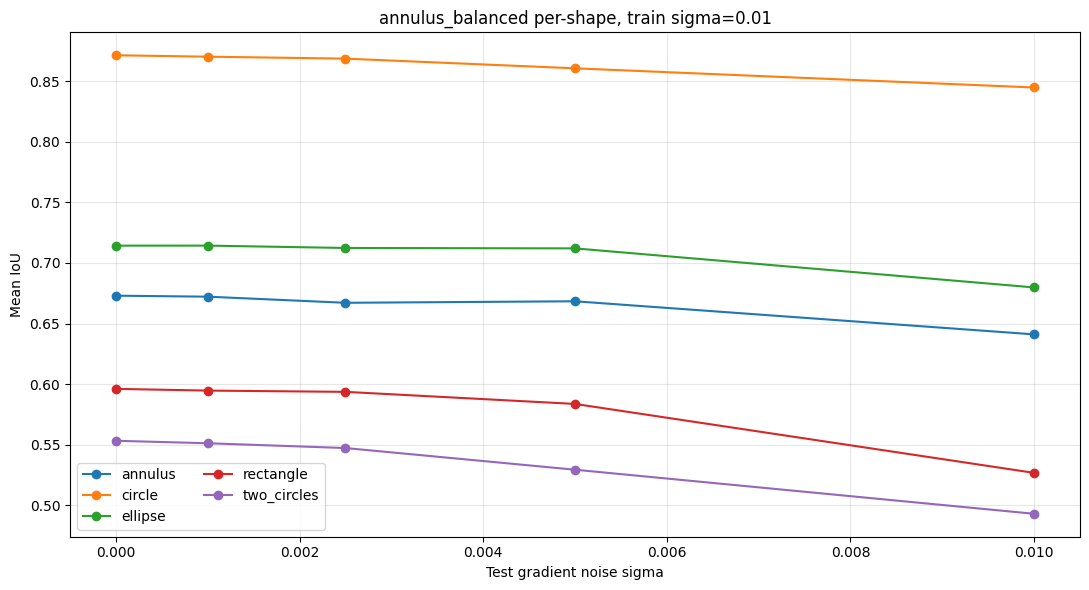


=== training sigma=0.01, condition=annulus_balanced_weighted ===


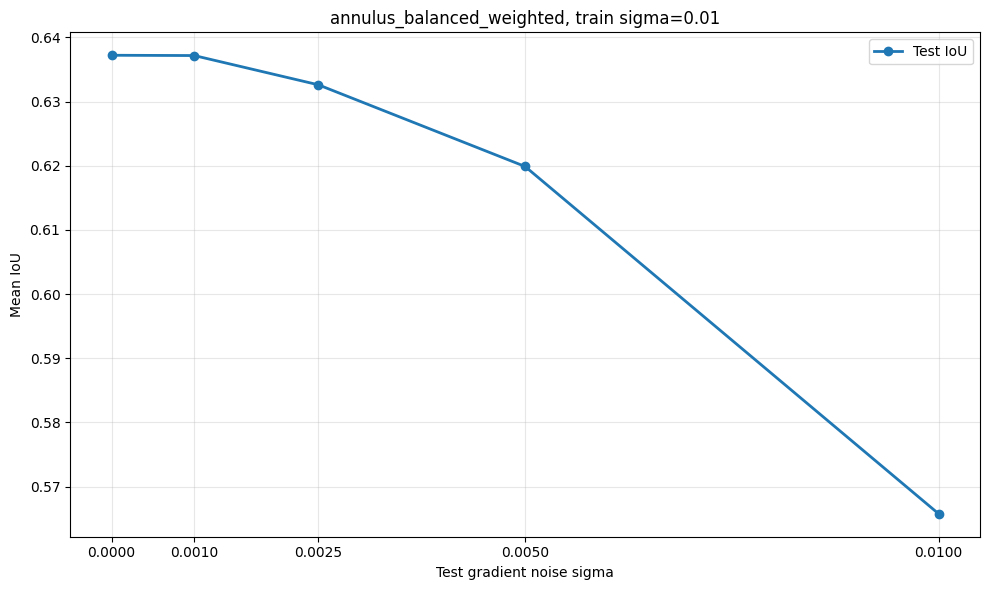

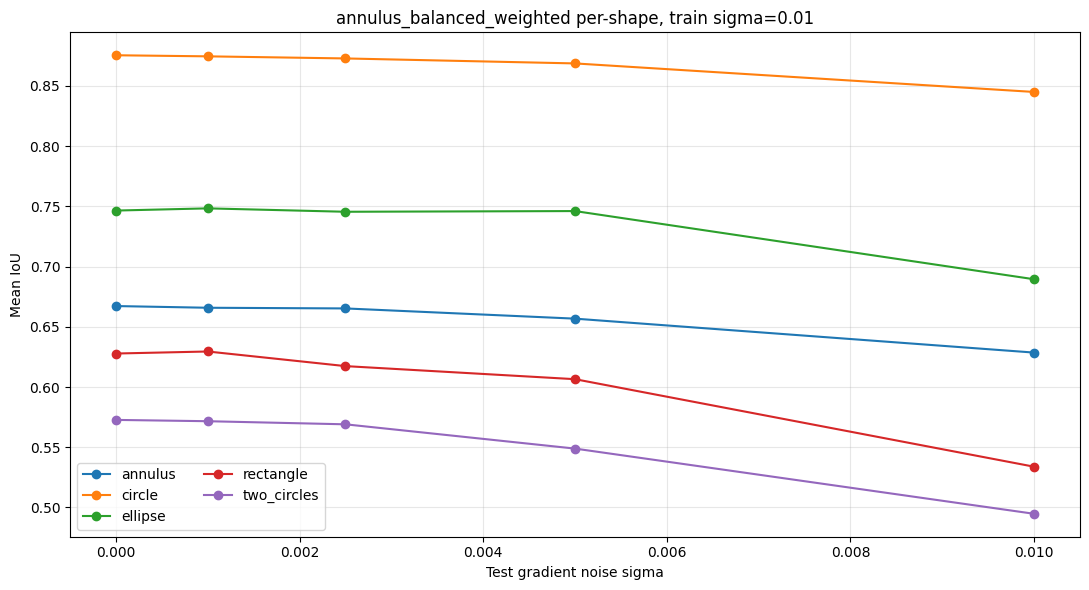

,train_sigma,condition,clean_test_iou,clean_annulus_iou,threshold
0,0.0000,baseline,0.801987,0.651980,0.7
2,0.0000,annulus_balanced_weighted,0.798467,0.674171,0.7
1,0.0000,annulus_balanced,0.792897,0.669300,0.7
3,0.0010,baseline,0.790067,0.649612,0.7
4,0.0010,annulus_balanced,0.780481,0.674155,0.7
5,0.0010,annulus_balanced_weighted,0.776089,0.670960,0.7
6,0.0025,baseline,0.754428,0.652669,0.7
8,0.0025,annulus_balanced_weighted,0.744984,0.673726,0.7
7,0.0025,annulus_balanced,0.737890,0.683085,0.7
9,0.0050,baseline,0.697944,0.648678,0.7


In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import torch

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from config import OneModelRunConfig, Stage2ModelConfig, StageTrainingConfig
from datasets import build_two_stage_datasets
from experiments import evaluate_noise_sweep, load_one_stage_predictor, save_noise_results, sigma_label
from experiments.notebook import plot_noise_curve, plot_shape_curves
from final_models.one_stage import run_one_stage

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT = ROOT / 'output' / 'experiments'
OUTPUT.mkdir(parents=True, exist_ok=True)
TRAIN_SIGMAS = (0.0, 0.001, 0.0025, 0.005, 0.01)
TEST_SIGMAS = TRAIN_SIGMAS
RUN_ABLATIONS = False
BASE_WEIGHTS = (('rectangle', 0.25), ('two_circles', 0.45), ('annulus', 0.10), ('ellipse', 0.15), ('circle', 0.05))
BALANCED_WEIGHTS = (('rectangle', 0.25), ('two_circles', 0.40), ('annulus', 0.20), ('ellipse', 0.10), ('circle', 0.05))
CONDITIONS = {'baseline': (BASE_WEIGHTS, 1.0), 'annulus_balanced': (BALANCED_WEIGHTS, 1.0), 'annulus_balanced_weighted': (BALANCED_WEIGHTS, 2.0)}

def make_config(train_sigma, name, weights, annulus_weight):
    train_dir = OUTPUT / f'train_sigma{sigma_label(train_sigma)}' / name
    model = Stage2ModelConfig(hidden_layer_sizes=(512, 1024), dropout_rates=(0.1, 0.1), model_type='coord_conv_decoder', latent_grid_size=16, latent_channels=160, decoder_channels=(160, 128, 96, 64, 32), use_rectangle_edge_weighting=True, rectangle_edge_weight=4.0, rectangle_edge_width=3, edge_weight_mode='all', annulus_edge_weight=annulus_weight, annulus_edge_width=3, training=StageTrainingConfig(epochs=80, batch_size=96, learning_rate=0.0005, validation_frequency=20, verbose=False, early_stopping_patience=15, min_epochs=30, min_improvement=0.001, lr_drop_factor=0.5, lr_drop_period=40, weight_decay=0.00025, gradient_clip_norm=0.8, loss_type='bce_dice', dice_loss_weight=1.0, dice_smooth=1.0))
    return OneModelRunConfig(N=10, training_samples=5_000, validation_samples=500, test_samples=500, noise_sigma=train_sigma, noise_mode='absolute', seed=42, training_noise_replicas=1, training_shape_weights=weights, use_validation_threshold_sweep=True, model=model, output_dir=train_dir)

results = []
for train_sigma in TRAIN_SIGMAS:
    for name, (weights, annulus_weight) in CONDITIONS.items():
        config = make_config(train_sigma, name, weights, annulus_weight)
        summary_path = config.run_output_dir / 'summary.json'
        should_train = RUN_ABLATIONS or not summary_path.exists()
        print(f'\n=== training sigma={train_sigma:g}, condition={name} ===')
        summary = run_one_stage(config, device=DEVICE) if should_train else json.loads(summary_path.read_text(encoding='utf-8'))
        bundle = build_two_stage_datasets(config)
        predict_logits, summary = load_one_stage_predictor(config.output_dir, config, DEVICE)
        threshold = float(summary['threshold_summary']['selected_threshold'])
        overall, by_shape = evaluate_noise_sweep(predict_logits, bundle.test.gradient_data, bundle.test.masks, bundle.test.shape_types, threshold, noise_levels=TEST_SIGMAS, seed=42)
        save_noise_results(overall, by_shape, config.output_dir, stem='test_noise_robustness')
        plot_noise_curve(overall, config.output_dir / 'test_noise_curve.png', f'{name}, train sigma={train_sigma:g}')
        plot_shape_curves(by_shape, config.output_dir / 'test_noise_by_shape.png', f'{name} per-shape, train sigma={train_sigma:g}')
        clean = overall[overall['noise_sigma'] == 0.0].iloc[0]
        annulus = by_shape[(by_shape['noise_sigma'] == 0.0) & (by_shape['shape'] == 'annulus')].iloc[0]
        results.append({'train_sigma': train_sigma, 'condition': name, 'clean_test_iou': clean['mean_iou'], 'clean_annulus_iou': annulus['mean_iou'], 'threshold': threshold})
comparison = pd.DataFrame(results).sort_values(['train_sigma', 'clean_test_iou'], ascending=[True, False])
comparison.to_csv(OUTPUT / 'ablation_training_noise_comparison.csv', index=False)
display(comparison)

The final noise levels are `0.0`, `0.001`, `0.0025`, `0.005`, and `0.01`. Mixed training is a training-distribution comparison, not test-time robustness. Fixed IoU remains diagnostic only.